In [3]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

In [21]:
# columns...
# 0: x1
# 1: x2
# 2: label
# two groups...
# A - gaussian at mu = (1, 1), stddev = 1
# B - gaussian at mu = (-1, -1), stddev = 1
# 50 points in each group

# generate data
rng = np.random.default_rng(12345)
n = 50
labels = [1.0] * n + [2.0] * n
x1 = rng.normal(loc=1, scale=1, size=2 * n)
x2 = rng.normal(loc=1, scale=1, size=2 * n)
x1[n:] *= -1
x2[n:] *= -1
df = pd.DataFrame({"x1": x1, "x2": x2, "label": labels})
df

,x1,x2,label
0,-0.423825,0.755447,1.0
1,2.263728,-0.995857,1.0
2,0.129338,0.844752,1.0
3,0.740827,2.063831,1.0
4,0.924657,0.724828,1.0
...,...,...,...
95,-0.938095,-1.686183,2.0
96,-0.640520,-2.215005,2.0
97,-0.251356,-1.216059,2.0
98,-0.034521,-0.035176,2.0


In [45]:
# df["label_text"] = df["label"].astype(int).astype(str)
# df = df.astype({"label_text": pd.CategoricalDtype(df["label_text"].unique(), ordered=True)})
df = df.astype({"label": "int"}).astype({"label": "str"}).astype({"label": "category"}).as_ordered()
df

,x1,x2,label,label_text
0,-0.423825,0.755447,1.0,1
1,2.263728,-0.995857,1.0,1
2,0.129338,0.844752,1.0,1
3,0.740827,2.063831,1.0,1
4,0.924657,0.724828,1.0,1
...,...,...,...,...
95,-0.938095,-1.686183,2.0,2
96,-0.640520,-2.215005,2.0,2
97,-0.251356,-1.216059,2.0,2
98,-0.034521,-0.035176,2.0,2


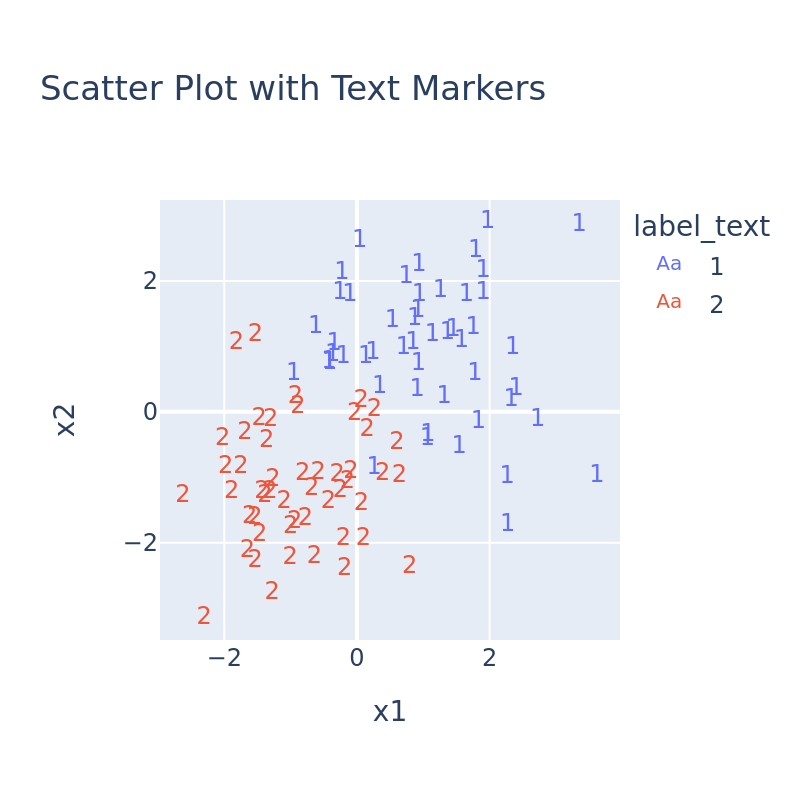

In [48]:
fig = px.scatter(
    df,
    x="x1",
    y="x2",
    color="label_text",
    text="label_text",
    title="Scatter Plot with Text Markers",
)
# text only, no markers
fig.update_traces(mode="text")
fig.for_each_trace(lambda t: t.update(textfont_color=t.marker.color))
# use the same color for text as for markers
# fig.update_traces(textfont_color=fig.data[0].marker.color)
# 400x400
fig.update_layout(width=400, height=400)
fig.show(renderer="png", scale=2)